In [1]:
pwd()


"/mnt/Dados/Documents/Felipe/Estudo/bolsa/Polyhedron/finding_polyhedrons"

In [15]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()
using LinearAlgebra, DelimitedFiles, JuMP, HiGHS, NEOSServer
include("Polyhedron.jl")
using .Poly

  Activating project at `~/Documents/Polyhedron`


In [51]:
A = [0.9666 0;
    0.0328 0.9666] 
B = [0.1980;
    0.0033;;]

C = [0 1]

T = 0.5
ref = 1//20

delta = 0.6

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -T 1 T; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/15 0
      0 1/15;
     -1/15 0;
      0 -1/15;]
Sv = [1/300;
      -1/300;]

Sw = [1/50;
      -1/50;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

# Fr para a referência
R = [1/15;
      -1/15;]

2-element Vector{Float64}:
  0.06666666666666667
 -0.06666666666666667

X[k+1] = (A+BK)X[k] + Er[1]

In [52]:
result = Poly.is_pinvariant_seg_ref(A_exp, B_exp, E_exp, S, R; lambda=0.999, ll = 20)

Dict{String, Matrix{Float64}} with 2 entries:
  "L" => [-0.00287375 -0.172112 0.011377 0.0142332; 4.77714e-5 0.0667969 -7.712…
  "K" => [-5.09931 -13.0257 0.861074 1.0772]

In [53]:
L = result["L"]
K = result["K"]

r = 10*ones(50)

function trajectory_seg_ref(x0, A, E,passos)
    for i in range(2, passos)
        try
            x0 = hcat(x0, A*x0[:, i-1] + E*r[i-1])    
        catch e
            print(e)
        end
        
    end
    return x0   
end

trajectory_seg_ref (generic function with 1 method)

In [47]:
av = eigvals(A_exp + B_exp*K)

4-element Vector{ComplexF64}:
 0.012470273935290141 + 0.0im
   0.9735045496294534 - 0.0045141070482844796im
   0.9735045496294534 + 0.0045141070482844796im
                 0.99 + 0.0im

In [54]:
x0 = [0;0; 0; 0]
x0 = trajectory_seg_ref(x0, A_exp + B_exp*K, E_exp, 50)

4×50 Matrix{Float64}:
 0.0  0.0  0.853143  1.6326     2.34486   …    9.80284    9.81785    9.83167
 0.0  0.0  0.014219  0.0551931  0.119679       6.67964    6.78378    6.88492
 0.0  0.0  2.0       5.19289    9.08529      148.596    150.256    151.864
 0.0  4.0  6.4       7.84       8.704         10.0       10.0       10.0

In [ ]:
size(x0)
x0[:, 50]

4-element Vector{Float64}:
   9.83166732778363
   6.884920980875514
 151.86424919777627
   9.999999999865285

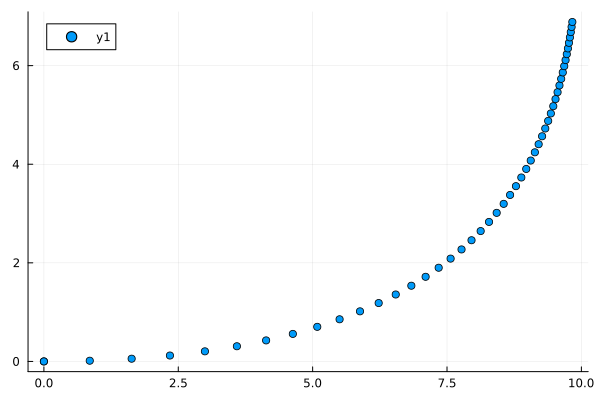

In [58]:
using Plots
scatter(x0[1,:], x0[2,:])

In [36]:
B_exp

4×1 Matrix{Float64}:
 0.198
 0.0033
 0.0
 0.0